In [1]:
from IPython import get_ipython

get_ipython().getoutput("wget -O 'Project_train.csv' 'https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/fcf0ec1f3785668db3f2122ed605ebc0/Project_train.csv'")
get_ipython().getoutput("wget -O 'Project_test.csv' 'https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/359662815ce4d41539803bd3dbc34ee3/Project_test.csv'")


['--2025-10-08 12:38:30--  https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/359662815ce4d41539803bd3dbc34ee3/Project_test.csv',
 'Resolving hr-projects-assets-prod.s3.amazonaws.com (hr-projects-assets-prod.s3.amazonaws.com)... 52.217.87.4, 16.182.40.129, 52.216.207.3, ...',
 'Connecting to hr-projects-assets-prod.s3.amazonaws.com (hr-projects-assets-prod.s3.amazonaws.com)|52.217.87.4|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 15910859 (15M) [binary/octet-stream]',
 'Saving to: ‘Project_test.csv’',
 '',
 '',
 'Project_test.csv      0%[                    ]       0  --.-KB/s               ',
 'Project_test.csv      1%[                    ] 296.55K  1.18MB/s               ',
 'Project_test.csv     33%[=====>              ]   5.07M  10.4MB/s               ',
 'Project_test.csv    100%[===================>]  15.17M  22.3MB/s    in 0.7s    ',
 '',
 '2025-10-08 12:38:31 (22.3 MB/s) - ‘Project_test.csv’ saved [15910859/15910859]',
 '']

In [2]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from itertools import product
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

### Setup ###

warnings.filterwarnings('ignore')
pl.seed_everything(42, workers=True)
NUM_WORKERS = os.cpu_count()


### Data Loading ###

df_train_val = pd.read_csv('Project_train.csv', index_col=0)

TARGET_COL = 'TARGET'
FEATURE_COLS = df_train_val.columns.drop(TARGET_COL)


### "PROFIT" metric ###
def total_profit_metric(y_true, y_pred, tau):
    """
    TODO
    """
    mask = y_pred > tau
    return np.sum(y_true[mask])


### torch.Dataset for sequence creation ###

class SequenceDataset(Dataset):
    """
    TODO
    """
    def __init__(self, features, targets, sequence_length=100):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return self.features.shape[0] - self.sequence_length

    def __getitem__(self, idx):
      """
      Notes
      -----
      - If idx = 10 and K=10, then end_idx - 1 = 19 and we have sequence from 10,..,19
      """

      end_idx = idx + self.sequence_length

      # The feature sequence from idx to end_idx - 1 (inclusive)
      feature_sequence = self.features[idx : end_idx]

      # Target corresponds end_idx - 1
      target = self.targets[end_idx - 1]

      return feature_sequence, target


### LSTM Model ###

class LSTMModel(nn.Module):

    def __init__(self, n_features, hidden_units, n_layers=1, dropout=0.05):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_units,
            batch_first=True,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0
        )
        self.linear = nn.Linear(in_features=hidden_units, out_features=1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        prediction = self.linear(last_time_step_out)
        return prediction.squeeze(-1)


### Custom Loss ###

class ProfitMaximizingLoss(nn.Module):
    """
    Custom loss -> Negative of a differentiable profit proxy.
    """
    def __init__(self, tau: float, sharpness: float = 10.0):
        super().__init__()
        self.tau = tau
        self.sharpness = sharpness

    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        trade_probability = torch.sigmoid(self.sharpness * (y_pred - self.tau))
        expected_profit = y_true * trade_probability

        return -torch.sum(expected_profit)


### Lightning Pipeline ###

class LSTMProfitModel(pl.LightningModule):
    """
    TODO
    """
    def __init__(self, n_features: int, hidden_units: int, learning_rate: float, tau: float):
        super().__init__()
        self.save_hyperparameters()
        self.model = LSTMModel(n_features=n_features, hidden_units=hidden_units)
        self.criterion = ProfitMaximizingLoss(tau=self.hparams.tau)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y_true = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y_true)
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=False)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y_true = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y_true)
        self.log('val_loss', loss, prog_bar=True)

        profit = total_profit_metric(y_true.cpu().numpy(), y_pred.cpu().numpy(), tau=self.hparams.tau)

        self.log('val_profit', profit, on_step=False, on_epoch=True, reduce_fx="sum")

        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, y = batch

        return self(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)


### Training Pipeline ###

def run_training_pipeline_pytorch(
    X_train_val,
    y_train_val,
    param_grid,
    n_splits=3,
    sequence_length=100,
):


    tscv = TimeSeriesSplit(n_splits=n_splits)
    results_summary = []
    best_overall_profit = -np.inf
    best_params = None

    param_combinations = list(product(
        param_grid['hidden_units'], param_grid['learning_rate'], param_grid['tau']
    ))

    for params in tqdm(param_combinations, desc="Hyperparameter Search"):
        hidden_units, learning_rate, tau = params
        current_params = {'hidden_units': hidden_units, 'learning_rate': learning_rate, 'tau': tau}

        fold_profits = []
        for fold, (train_index, val_index) in enumerate(tscv.split(X_train_val)):
            X_train, X_val = X_train_val[train_index], X_train_val[val_index]
            y_train, y_val = y_train_val[train_index], y_train_val[val_index]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            train_dataset = SequenceDataset(X_train_scaled, y_train, sequence_length)
            val_dataset = SequenceDataset(X_val_scaled, y_val, sequence_length)

            if len(val_dataset) == 0: continue

            train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
            val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

            model = LSTMProfitModel(n_features=X_train_val.shape[1], **current_params)

            checkpoint_callback = ModelCheckpoint(monitor='val_profit', mode='max')
            early_stop_callback = EarlyStopping(monitor='val_profit', patience=5, mode='max', verbose=False)

            trainer = pl.Trainer(
                max_epochs=20,
                callbacks=[checkpoint_callback, early_stop_callback],
                accelerator='auto',
                logger=False,
                enable_progress_bar=True,
                enable_model_summary=True
            )

            trainer.fit(model, train_loader, val_loader)

            # Validate on best model from this fold
            val_results = trainer.validate(dataloaders=val_loader, ckpt_path='best', verbose=False)
            fold_profits.append(val_results[0]['val_profit'])

        mean_profit = np.mean(fold_profits) if fold_profits else 0
        results_summary.append({**current_params, 'mean_PROFIT': mean_profit})

        if mean_profit > best_overall_profit:
            best_overall_profit = mean_profit
            best_params = current_params

    results_df = pd.DataFrame(results_summary).sort_values(by='mean_PROFIT', ascending=False).reset_index(drop=True)
    print(results_df.to_string())

    print(f"\nBest Overall Model Params: {best_params}")
    print(f"Achieved an average PROFIT of {best_overall_profit:.4f} across validation folds.")

    return {'results_df': results_df, 'best_params': best_params}


### Out of Fold Predictions ###

def generate_oof_predictions_pytorch(
    best_params, X, y, n_splits=3, sequence_length=100
):
    oof_preds = np.full(y.shape, np.nan)
    oof_true = np.full(y.shape, np.nan)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for fold, (train_index, val_index) in enumerate(tscv.split(X)):
        print(f"--- OOF Fold {fold+1}/{n_splits} ---")

        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        train_dataset = SequenceDataset(X_train_scaled, y_train, sequence_length)
        val_dataset = SequenceDataset(X_val_scaled, y_val, sequence_length)

        if len(val_dataset) == 0: continue

        target_indices = val_index[sequence_length - 1 : len(val_index) - 1]

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

        model = LSTMProfitModel(n_features=X.shape[1], **best_params)

        trainer = pl.Trainer(
            max_epochs=20,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, mode='min')],
            accelerator='auto',
            logger=False,
            enable_progress_bar=True
        )

        trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

        raw_predictions = trainer.predict(dataloaders=val_loader)
        predictions_tensor = torch.cat(raw_predictions)

        oof_preds[target_indices] = predictions_tensor.numpy()
        oof_true[target_indices] = y[target_indices]

    valid_mask = ~np.isnan(oof_preds)
    return oof_true[valid_mask], oof_preds[valid_mask]


### Plotting Logic ###

def plot_cumulative_profit(y_true, y_pred, tau, title="Cumulative Profit"):

    results_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    results_df['profit'] = np.where(results_df['y_pred'] > tau, results_df['y_true'], 0.0)
    results_df['cumulative_profit'] = results_df['profit'].cumsum()
    results_df['trade_all'] = results_df['y_true'].cumsum()

    plt.figure(figsize=(12, 7))
    results_df['cumulative_profit'].plot(label='LSTM Model Strategy', lw=2.5, color='royalblue')
    results_df['trade_all'].plot(label='Trade All (Benchmark)', linestyle='--', color='gray', lw=2)
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Cumulative Profit', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()

    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, tau, title="Predicted vs. Actual Profit"):

    plt.figure(figsize=(9, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, s=50, label='Trades')
    plt.axvline(0, color='black', linestyle='-', lw=1)
    plt.title(title, fontsize=16)
    plt.xlabel('Actual Profit', fontsize=12)
    plt.ylabel('Predicted Profit', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()

    plt.show()

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [11]:

X_train_val = df_train_val[['4', '6', '10', '0', '12', '50', '21', '24', '8', '26']].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

PARAM_GRID_LSTM = {
  'hidden_units': [64, 128],
  'learning_rate': [1e-3],
  'tau': [0]
}

training_results = run_training_pipeline_pytorch(
  X_train_val=X_train_val,
  y_train_val=y_train_val,
  param_grid=PARAM_GRID_LSTM
)

Hyperparameter Search:   0%|          | 0/2 [00:00<?, ?it/s]INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                 | Params | Mode 
-----------------------------------------------------------
0 | model     | LSTMModel            | 19.5 K | train
1 | criterion | ProfitMaximizingLoss | 0      | train
-----------------------------------------------------------
19.5 K    Trainable params
0         Non-trainable params
19.5 K    Total params
0.078     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/epoch=0-step=1054.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/epoch=0-step=1054.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

Hyperparameter Search: 100%|██████████| 2/2 [05:28<00:00, 164.34s/it]

   hidden_units  learning_rate  tau  mean_PROFIT
0            64          0.001    0     5.934799
1           128          0.001    0     5.296816

Best Overall Model Params: {'hidden_units': 64, 'learning_rate': 0.001, 'tau': 0}
Achieved an average PROFIT of 5.9348 across validation folds.


In [12]:
best_params = training_results['best_params']
y_true_oof, y_pred_oof = generate_oof_predictions_pytorch(
    best_params=best_params, X=X_train_val, y=y_train_val
)


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                 | Params | Mode 
-----------------------------------------------------------
0 | model     | LSTMModel            | 19.5 K | train
1 | criterion | ProfitMaximizingLoss | 0      | train
-----------------------------------------------------------
19.5 K    Trainable params
0         Non-trainable params
19.5 K    Total params
0.078     Tot

--- OOF Fold 1/3 ---


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/epoch=12-step=13702.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/epoch=12-step=13702.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

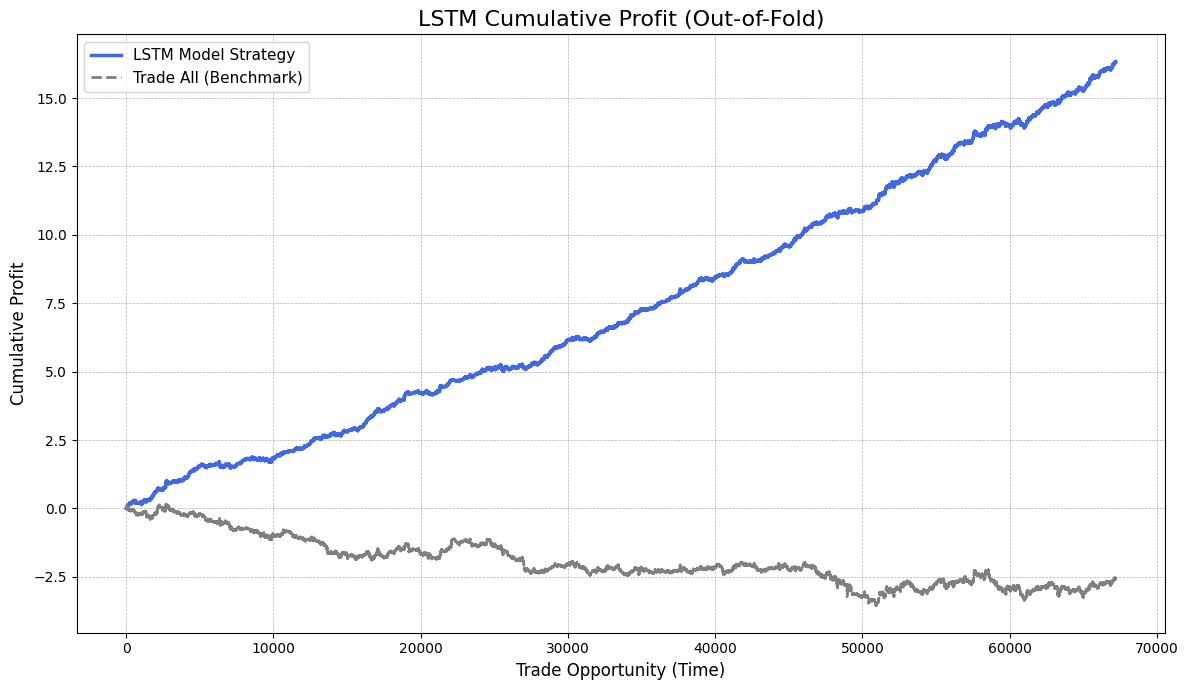

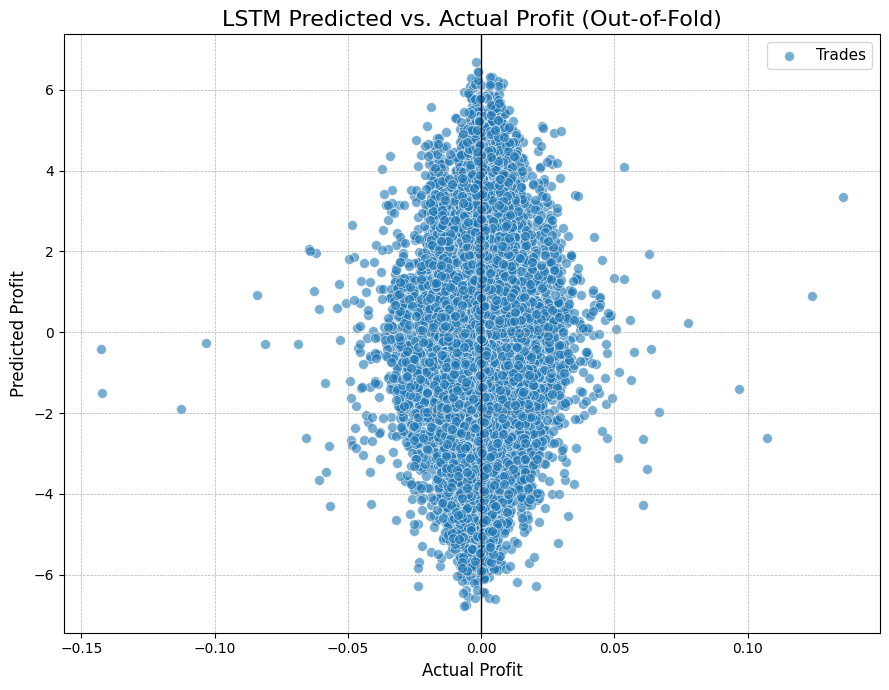

In [13]:
plot_cumulative_profit(
    y_true_oof, y_pred_oof, best_params['tau'],
    title="LSTM Cumulative Profit (Out-of-Fold)"
)
plot_predicted_vs_actual(
    y_true_oof, y_pred_oof, best_params['tau'],
    title="LSTM Predicted vs. Actual Profit (Out-of-Fold)"
)